### **Assignment Setup**
* Import Libraries
* Load Datasets

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [30]:
# ---------------------------------------------------------
# LOAD DATASETS FROM GITHUB
# ---------------------------------------------------------
QB_URL = "https://raw.githubusercontent.com/dtavizondykstra/BU_Datasets/refs/heads/main/DSC320_MathForDataScience/wk9_qb_stats.csv"
SURVEY_URL = "https://raw.githubusercontent.com/dtavizondykstra/BU_Datasets/refs/heads/main/DSC320_MathForDataScience/wk9_survey_data.csv"

df_qb = pd.read_csv(QB_URL)
df_survey = pd.read_csv(SURVEY_URL)

print("QB Stats — shape:", df_qb.shape)
print(df_qb.head(3))
print()
print("Survey Data — shape:", df_survey.shape)
print(df_survey.head(3))

QB Stats — shape: (32, 13)
             name team  games    att    cmp  comp_pct     yds  ypa    td  int  \
0  Ryan Tannehill  TEN   12.0  286.0  201.0      70.3  2742.0  9.6  22.0  6.0   
1      Drew Brees   NO   11.0  378.0  281.0      74.3  2979.0  7.9  27.0  4.0   
2   Lamar Jackson  BAL   15.0  401.0  265.0      66.1  3127.0  7.8  36.0  6.0   

   sack   loss  rating  
0  31.0  212.0   117.5  
1  12.0   89.0   116.3  
2  23.0  106.0   113.3  

Survey Data — shape: (162, 2)
  hair_color eye_color
0      brown     brown
1      brown     brown
2      brown      blue


# **Problem 1: Summarizing Data**

The dataset `qb_stats.csv` contains NFL quarterback statistics from the 2019 regular season. \
Each row represents one quarterback and includes columns for games played, pass attempts, \
completions, completion percentage, yards, yards per attempt, touchdowns, interceptions, \
sacks, and quarterback rating.

## **Problem 1a**

Find the mean of each numerical column of data.

In [31]:
# ---------------------------------------------------------
# PROBLEM 1A: MEAN OF EACH NUMERICAL COLUMN
# ---------------------------------------------------------
numeric_cols = df_qb.select_dtypes(include=[np.number]).columns

means = df_qb[numeric_cols].mean()

print("Column Means:")
print("-" * 38)
for col, val in means.items():
    print(f"{col:<28} {val:>8.3f}")

Column Means:
--------------------------------------
games                          14.125
att                           478.406
cmp                           306.562
comp_pct                       64.297
yds                          3515.062
ypa                             7.375
td                             22.375
int                            10.344
sack                           32.312
loss                          217.094
rating                         93.388


**Answer**: The table above shows the mean for each numerical column in the quarterback dataset. 

## **Problem 1b**

Find the standard deviation of each numerical column of data.

In [32]:
# ---------------------------------------------------------
# PROBLEM 1B: STANDARD DEVIATION OF EACH NUMERICAL COLUMN
# ---------------------------------------------------------
stds = df_qb[numeric_cols].std()

print("Column Standard Deviations:")
print("-" * 38)
for col, val in stds.items():
    print(f"{col:<28} {val:>8.3f}")

Column Standard Deviations:
--------------------------------------
games                           2.406
att                           110.360
cmp                            68.930
comp_pct                        3.628
yds                           852.437
ypa                             0.797
td                              6.257
int                             5.840
sack                           10.514
loss                           70.786
rating                         11.055


**Answer**: The standard deviation measures how spread out each column's values are around the mean. Columns that draw immediate attention are yards and attempts, which show high standard deviations. Meanwhile, yards per attempt and completion percentage have lower standard deviations.

## **Problem 1c**

Create a histogram of the number of yards; label it appropriately.

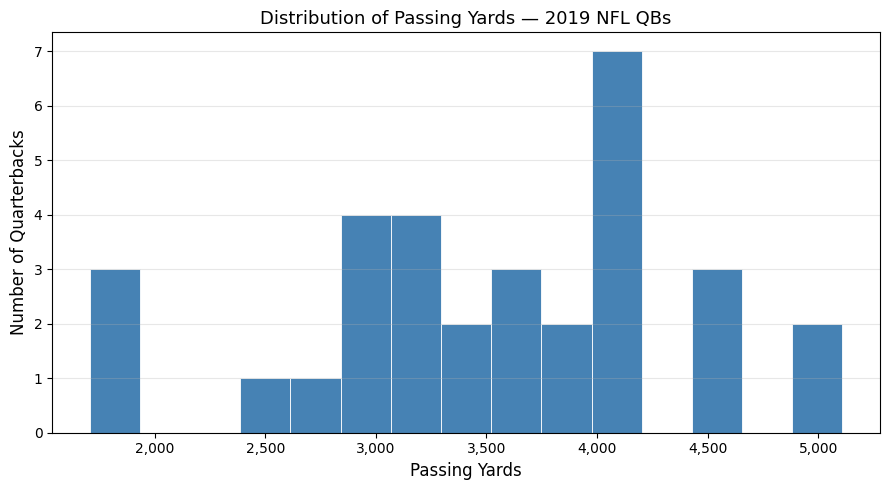


Yards — min: 1707, median: 3566.0, mean: 3515.1, max: 5109


In [33]:
# ---------------------------------------------------------
# PROBLEM 1C: HISTOGRAM OF PASSING YARDS
# ---------------------------------------------------------
yards_col = "yds"

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(
    df_qb[yards_col].dropna(),
    bins=15,
    color="steelblue",
    edgecolor="white",
    linewidth=0.6,
)
ax.set_xlabel("Passing Yards", fontsize=12)
ax.set_ylabel("Number of Quarterbacks", fontsize=12)
ax.set_title("Distribution of Passing Yards — 2019 NFL QBs", fontsize=13)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nYards — min: {df_qb[yards_col].min():.0f}, "
      f"median: {df_qb[yards_col].median():.1f}, "
      f"mean: {df_qb[yards_col].mean():.1f}, "
      f"max: {df_qb[yards_col].max():.0f}")
      

**Answer**: The histogram shows a left-skewed distribution of passing yards. The fact that the median is higher than the mean confirms that more than half of the quarterbacks in this 2019 dataset performed better than the "average" yardage would suggest.

## **Problem 1d**

Create a boxplot of the number of touchdowns. Identify any outliers.

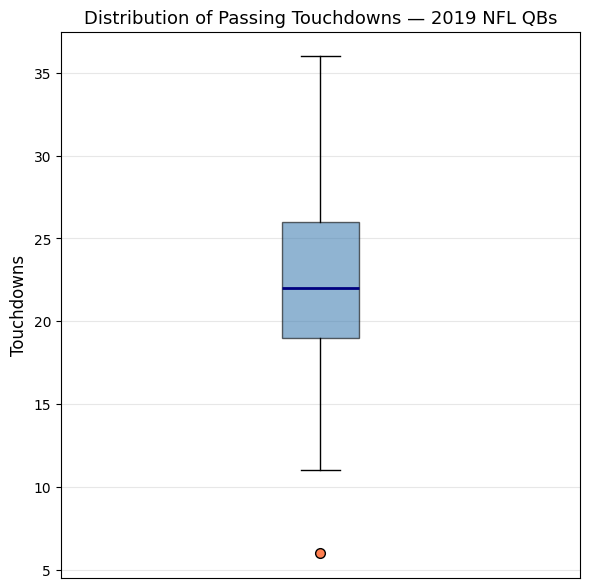

Q1: 19.0  |  Q3: 26.0  |  IQR: 7.0
Lower fence: 8.5  |  Upper fence: 36.5

Outliers detected:
  Joe Flacco: 6.0 TDs


In [34]:
# ---------------------------------------------------------
# PROBLEM 1D: BOXPLOT OF TOUCHDOWNS + OUTLIER IDENTIFICATION
# ---------------------------------------------------------
# IQR method: outliers lie below Q1 - 1.5*IQR or above Q3 + 1.5*IQR.

# Column is named "td" in this dataset
td_col = "td"
td = df_qb[td_col].dropna()

q1, q3   = td.quantile(0.25), td.quantile(0.75)
iqr      = q3 - q1
low_fence  = q1 - 1.5 * iqr
high_fence = q3 + 1.5 * iqr

outliers = df_qb[df_qb[td_col] < low_fence].copy()
outliers = pd.concat([outliers, df_qb[df_qb[td_col] > high_fence]])

fig, ax = plt.subplots(figsize=(6, 6))
ax.boxplot(
    td,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
    medianprops=dict(color="navy", linewidth=2),
    flierprops=dict(marker="o", markerfacecolor="coral", markersize=7),
)
ax.set_ylabel("Touchdowns", fontsize=12)
ax.set_title("Distribution of Passing Touchdowns — 2019 NFL QBs", fontsize=13)
ax.set_xticks([])
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Q1: {q1:.1f}  |  Q3: {q3:.1f}  |  IQR: {iqr:.1f}")
print(f"Lower fence: {low_fence:.1f}  |  Upper fence: {high_fence:.1f}")
print()
if outliers.empty:
    print("No outliers detected.")
else:
    name_col = df_qb.columns[0]
    print("Outliers detected:")
    for _, row in outliers.iterrows():
        print(f"  {row[name_col]}: {row[td_col]} TDs")

**Answer**: Joe Flacco has been detected as an outlier with only six touchdowns.

# **Problem 2: Calculating Probabilities from Data**

The dataset `survey_data.csv` contains survey responses from college students reporting \
their hair color and eye color. All probabilities below are estimated directly from this \
sample.

In [35]:
# ---------------------------------------------------------
# PROBLEM 2: PREVIEW SURVEY DATA
# ---------------------------------------------------------
print("Columns:", df_survey.columns.tolist())
print()
print("Hair color counts:")
hair_col = df_survey.columns[0]
eye_col  = df_survey.columns[1]
print(df_survey[hair_col].value_counts())
print()
print("Eye color counts:")
print(df_survey[eye_col].value_counts())

Columns: ['hair_color', 'eye_color']

Hair color counts:
hair_color
brown     83
blonde    38
black     22
red        9
blond      5
other      3
gray       1
white      1
Name: count, dtype: int64

Eye color counts:
eye_color
brown    64
green    41
blue     40
other     9
black     8
Name: count, dtype: int64


## **Problem 2a**

Based on this data, what is the probability a college student has brown hair?

In [36]:
# ---------------------------------------------------------
# PROBLEM 2A: P(brown hair)
# ---------------------------------------------------------
total = len(df_survey)
n_brown_hair = (df_survey[hair_col].str.lower() == "brown").sum()
p_brown_hair = n_brown_hair / total

print(f"Total students: {total}")
print(f"Students with brown hair: {n_brown_hair}")
print(f"P(brown hair) = {n_brown_hair}/{total} = {p_brown_hair:.4f}  ({p_brown_hair:.1%})")

Total students: 162
Students with brown hair: 83
P(brown hair) = 83/162 = 0.5123  (51.2%)


**Answer**: The probability that a randomly selected student from this sample has brown hair is 51.2%. Which is calculated by dividing the number of students with brown hair by the total number of students surveyed (simple probability).

## **Problem 2b**

Based on this data, what is the probability a college student has blue eyes?

In [37]:
# ---------------------------------------------------------
# PROBLEM 2B: P(blue eyes)
# ---------------------------------------------------------
n_blue_eyes = (df_survey[eye_col].str.lower() == "blue").sum()
p_blue_eyes = n_blue_eyes / total

print(f"Students with blue eyes: {n_blue_eyes}")
print(f"P(blue eyes) = {n_blue_eyes}/{total} = {p_blue_eyes:.4f} ({p_blue_eyes:.1%})")

Students with blue eyes: 40
P(blue eyes) = 40/162 = 0.2469 (24.7%)


**Answer**: The probability that a randomly selected student has blue eyes is 24.7%, which is calculated by dividing the count of blue-eyed students by the total sample size (simple probability).

## **Problem 2c**

Based on this data, what is the probability a college student has blue eyes **given that** \
they have brown hair?  $P(\text{blue eyes} \mid \text{brown hair})$

In [38]:
# ---------------------------------------------------------
# PROBLEM 2C: P(blue eyes | brown hair)
# ---------------------------------------------------------
# Conditional probability: restrict to students with brown hair, then count blue eyes.
brown_hair_mask = df_survey[hair_col].str.lower() == "brown"
n_blue_given_brown = (
    (brown_hair_mask) & (df_survey[eye_col].str.lower() == "blue")
).sum()

p_blue_given_brown = n_blue_given_brown / n_brown_hair

print(f"Students with brown hair: {n_brown_hair}")
print(f"Of those, students with blue eyes: {n_blue_given_brown}")
print(f"P(blue eyes | brown hair) = {n_blue_given_brown}/{n_brown_hair} = {p_blue_given_brown:.4f}  ({p_blue_given_brown:.1%})")

Students with brown hair: 83
Of those, students with blue eyes: 18
P(blue eyes | brown hair) = 18/83 = 0.2169  (21.7%)


**Answer**: To find this conditional probability, we restrict the sample to only those students with brown hair and then calculate the proportion of that subgroup who also have blue eyes, resulting in a probability of 21.7%.

## **Problem 2d**

Based on this data, what is the probability a college student has brown hair **given that** \
they have blue eyes?  $P(\text{brown hair} \mid \text{blue eyes})$

In [39]:
# ---------------------------------------------------------
# PROBLEM 2D: P(brown hair | blue eyes)
# ---------------------------------------------------------
blue_eyes_mask = df_survey[eye_col].str.lower() == "blue"
n_brown_given_blue = (
    (blue_eyes_mask) & (df_survey[hair_col].str.lower() == "brown")
).sum()

p_brown_given_blue = n_brown_given_blue / n_blue_eyes

print(f"Students with blue eyes: {n_blue_eyes}")
print(f"Of those, students with brown hair: {n_brown_given_blue}")
print(f"P(brown hair | blue eyes) = {n_brown_given_blue}/{n_blue_eyes} = {p_brown_given_blue:.4f}  ({p_brown_given_blue:.1%})")

Students with blue eyes: 40
Of those, students with brown hair: 18
P(brown hair | blue eyes) = 18/40 = 0.4500  (45.0%)


**Answer**: Here we reverse the condition from the previous cell — restricting to blue-eyed students and calculating the proportion who also have brown hair, resulting in a probability of 45%. Note that $P(\text{blue eyes} \mid \text{brown hair}) \neq P(\text{brown hair} \mid \text{blue eyes})$, which illustrates why the direction of a conditional probability matters.

## **Problem 2e**

Do your results above indicate that having brown hair and blue eyes are **independent** \
of one another? Explain.

Two events A and B are independent if and only if:
$$P(A \cap B) = P(A) \times P(B)$$

In [40]:
# ---------------------------------------------------------
# PROBLEM 2E: INDEPENDENCE CHECK
# ---------------------------------------------------------
# If brown hair and blue eyes are independent:
#   P(brown hair AND blue eyes) should equal P(brown hair) * P(blue eyes).

n_brown_and_blue = (
    (df_survey[hair_col].str.lower() == "brown") &
    (df_survey[eye_col].str.lower() == "blue")
).sum()

p_brown_and_blue = n_brown_and_blue / total # observed joint probability
p_independent_expected  = p_brown_hair * p_blue_eyes  # expected if independent

print(f"P(brown hair) = {p_brown_hair:.4f}")
print(f"P(blue eyes) = {p_blue_eyes:.4f}")
print()
print(f"P(brown hair AND blue eyes) observed = {p_brown_and_blue:.4f}")
print(f"P(brown hair) x P(blue eyes) expected = {p_independent_expected:.4f}")
print()
diff = abs(p_brown_and_blue - p_independent_expected)
print(f"Difference = {diff:.4f}")

# Also confirm via conditional probability:
# If independent, P(blue eyes | brown hair) should equal P(blue eyes).
print()
print(f"P(blue eyes | brown hair) = {p_blue_given_brown:.4f}")
print(f"P(blue eyes) = {p_blue_eyes:.4f}")
print()
if diff < 0.01:
    print("Conclusion: The variables appear to be approximately independent.")
else:
    print("Conclusion: The variables do NOT appear to be independent.")

P(brown hair) = 0.5123
P(blue eyes) = 0.2469

P(brown hair AND blue eyes) observed = 0.1111
P(brown hair) x P(blue eyes) expected = 0.1265

Difference = 0.0154

P(blue eyes | brown hair) = 0.2169
P(blue eyes) = 0.2469

Conclusion: The variables do NOT appear to be independent.


**Answer**: Based on the provided dataset, brown hair and blue eyes are not independent events; they are statistically dependent. In probability, two events are independent only if the occurrence of one does not change the likelihood of the other, meaning $P(A \mid B)$ must equal $P(A)$. However, in this sample, the general probability of a student having blue eyes is approximately 24.7%, while the probability of having blue eyes specifically given that they have brown hair drops to 21.7%. Because knowing the student's hair color changes the predicted probability of their eye color, the traits are dependent. This deviation indicates a slight negative correlation within this specific group of students, as blue eyes appear less frequently among those with brown hair than they do in the overall population.

## **Problem 2f**

Create a bar graph of the hair color and eye color of this group of students. \
Label the graphs appropriately.

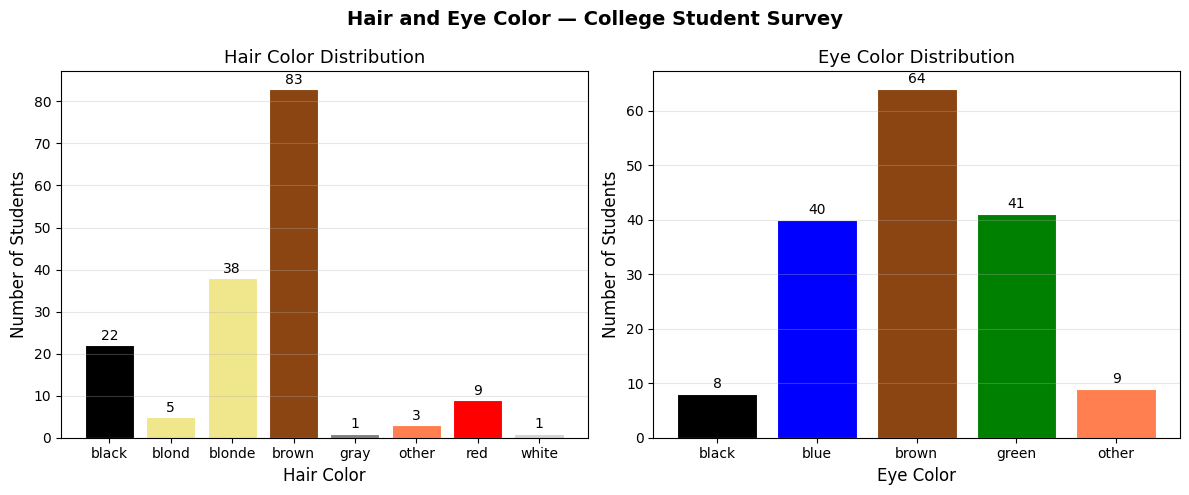

In [41]:
# ---------------------------------------------------------
# PROBLEM 2F: BAR GRAPHS — HAIR COLOR AND EYE COLOR
# ---------------------------------------------------------

hair_counts = df_survey[hair_col].value_counts().sort_index()
eye_counts  = df_survey[eye_col].value_counts().sort_index()

# Map categories to colors
hair_color_map = {
    "black": "black",
    "blonde": "khaki",
    "blond": "khaki",
    "brown": "saddlebrown",
    "red": "red",
    "gray": "gray",
    "white": "lightgray",
    "other": "coral"
}

eye_color_map = {
    "blue": "blue",
    "brown": "saddlebrown",
    "green": "green",
    "black": "black",
    "other": "coral"
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Hair color bar chart
h_colors = [hair_color_map.get(c, "steelblue") for c in hair_counts.index]
axes[0].bar(hair_counts.index, hair_counts.values, color=h_colors, edgecolor="white", linewidth=0.8)
axes[0].set_xlabel("Hair Color", fontsize=12)
axes[0].set_ylabel("Number of Students", fontsize=12)
axes[0].set_title("Hair Color Distribution", fontsize=13)
for bar, val in zip(axes[0].patches, hair_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 str(val), ha="center", va="bottom", fontsize=10)
axes[0].grid(axis="y", alpha=0.3)

# Eye color bar chart
e_colors = [eye_color_map.get(c, "coral") for c in eye_counts.index]
axes[1].bar(eye_counts.index, eye_counts.values, color=e_colors, edgecolor="white", linewidth=0.8)
axes[1].set_xlabel("Eye Color", fontsize=12)
axes[1].set_ylabel("Number of Students", fontsize=12)
axes[1].set_title("Eye Color Distribution", fontsize=13)
for bar, val in zip(axes[1].patches, eye_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 str(val), ha="center", va="bottom", fontsize=10)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Hair and Eye Color — College Student Survey", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Answer**: The two bar charts display the frequency distribution of hair color and eye color across the surveyed students. Brown is the dominant color for both Hair and Eye Color Distributions.